# Cohort EDA
Exploratory data analysis for the cohort.

In [1]:
# ── 0. imports & connection ───────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector

load_dotenv()


def get_cohort():
    conn = snowflake.connector.connect(
        user=os.getenv("SNOWFLAKE_USER"),
        password=os.getenv("SNOWFLAKE_PAT"),
        account=os.getenv("SNOWFLAKE_ACCOUNT"),
        warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
        database=os.getenv("SNOWFLAKE_DATABASE"),
        schema=os.getenv("SNOWFLAKE_SCHEMA"),
    )
    df = pd.read_sql("SELECT * FROM mart_analysis_cohort", conn)
    conn.close()
    return df


df = get_cohort()
print(f"Cohort size: {df.shape[0]:,} stays | {df.shape[1]} columns")


C:\Users\nickl\AppData\Local\Temp\ipykernel_34092\2121666483.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM mart_analysis_cohort", conn)


Cohort size: 10,964 stays | 24 columns


In [2]:
df = df.convert_dtypes().convert_dtypes(
    {
        "bun": float,
        "creatinine": float,
        "bilirubin": float,
        "platelets": float,
        "wbc": float,
        "lactate": float,
        "bicarbonate": float,
    }
)

In [3]:
# ── 1. basic cohort sanity checks ─────────────────────────────────────────────
# These numbers should make clinical sense before you go any further
df.columns = df.columns.str.lower()

print("=== Treatment group distribution ===")
print(df["treatment_label"].value_counts())
print(f"\nVasopressor rate: {df['treatment_group'].mean():.1%}")

print("\n=== 28-day mortality by group ===")
print(df.groupby("treatment_label")["outcome_mortality_28d"].agg(["mean", "count"]))

print("\n=== Age distribution ===")
print(df["age_at_admission"].describe().round(1))

print("\n=== ICU LOS (days) ===")
print(df["icu_los_days"].describe().round(1))

# Sanity check: no one should have negative time_to_event
assert (df["time_to_event_days"] >= 0).all(), (
    "Negative time-to-event detected — check index date logic"
)
print("\n✓ time_to_event_days all non-negative")


=== Treatment group distribution ===
treatment_label
vasopressor    6023
fluid_only     4941
Name: count, dtype: Int64

Vasopressor rate: 54.9%

=== 28-day mortality by group ===
                     mean  count
treatment_label                 
fluid_only       0.173447   4941
vasopressor       0.31994   6023

=== Age distribution ===
count    10964.0
mean        65.6
std         14.9
min         18.0
25%         57.0
50%         67.0
75%         77.0
max         89.0
Name: age_at_admission, dtype: Float64

=== ICU LOS (days) ===
count    10964.0
mean         5.9
std          7.9
min          0.2
25%          1.5
50%          2.9
75%          6.9
max        127.9
Name: icu_los_days, dtype: Float64

✓ time_to_event_days all non-negative


In [4]:
# ── 2. missingness report ─────────────────────────────────────────────────────
# Critical before PSM — you need to know what to impute

missing = (
    df.isnull()
    .sum()
    .rename("n_missing")
    .to_frame()
    .assign(pct_missing=lambda x: (x["n_missing"] / len(df) * 100).round(1))
    .sort_values("pct_missing", ascending=False)
)

print("=== Missingness report ===")
print(missing[missing["n_missing"] > 0].to_string())


=== Missingness report ===
             n_missing  pct_missing
bilirubin         5885         53.7
lactate           3841         35.0
wbc               2898         26.4
platelets         2886         26.3
bicarbonate       2541         23.2
bun               2545         23.2
creatinine        2534         23.1
insurance          112          1.0


In [5]:
# ── 3. define covariate lists ─────────────────────────────────────────────────
# Separating these out now makes PSM notebook cleaner

CONTINUOUS_COVARIATES = [
    "age_at_admission",
    "icu_los_days",
    "total_fluid_ml",
    "bun",
    "creatinine",
    "bilirubin",
    "platelets",
    "wbc",
    "lactate",
    "bicarbonate",
]

CATEGORICAL_COVARIATES = ["gender", "race", "insurance"]

OUTCOME_COLS = ["outcome_mortality_28d", "time_to_event_days", "event_observed"]

IDENTIFIER_COLS = ["subject_id", "hadm_id", "stay_id", "index_date"]


In [6]:
for col in CONTINUOUS_COVARIATES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

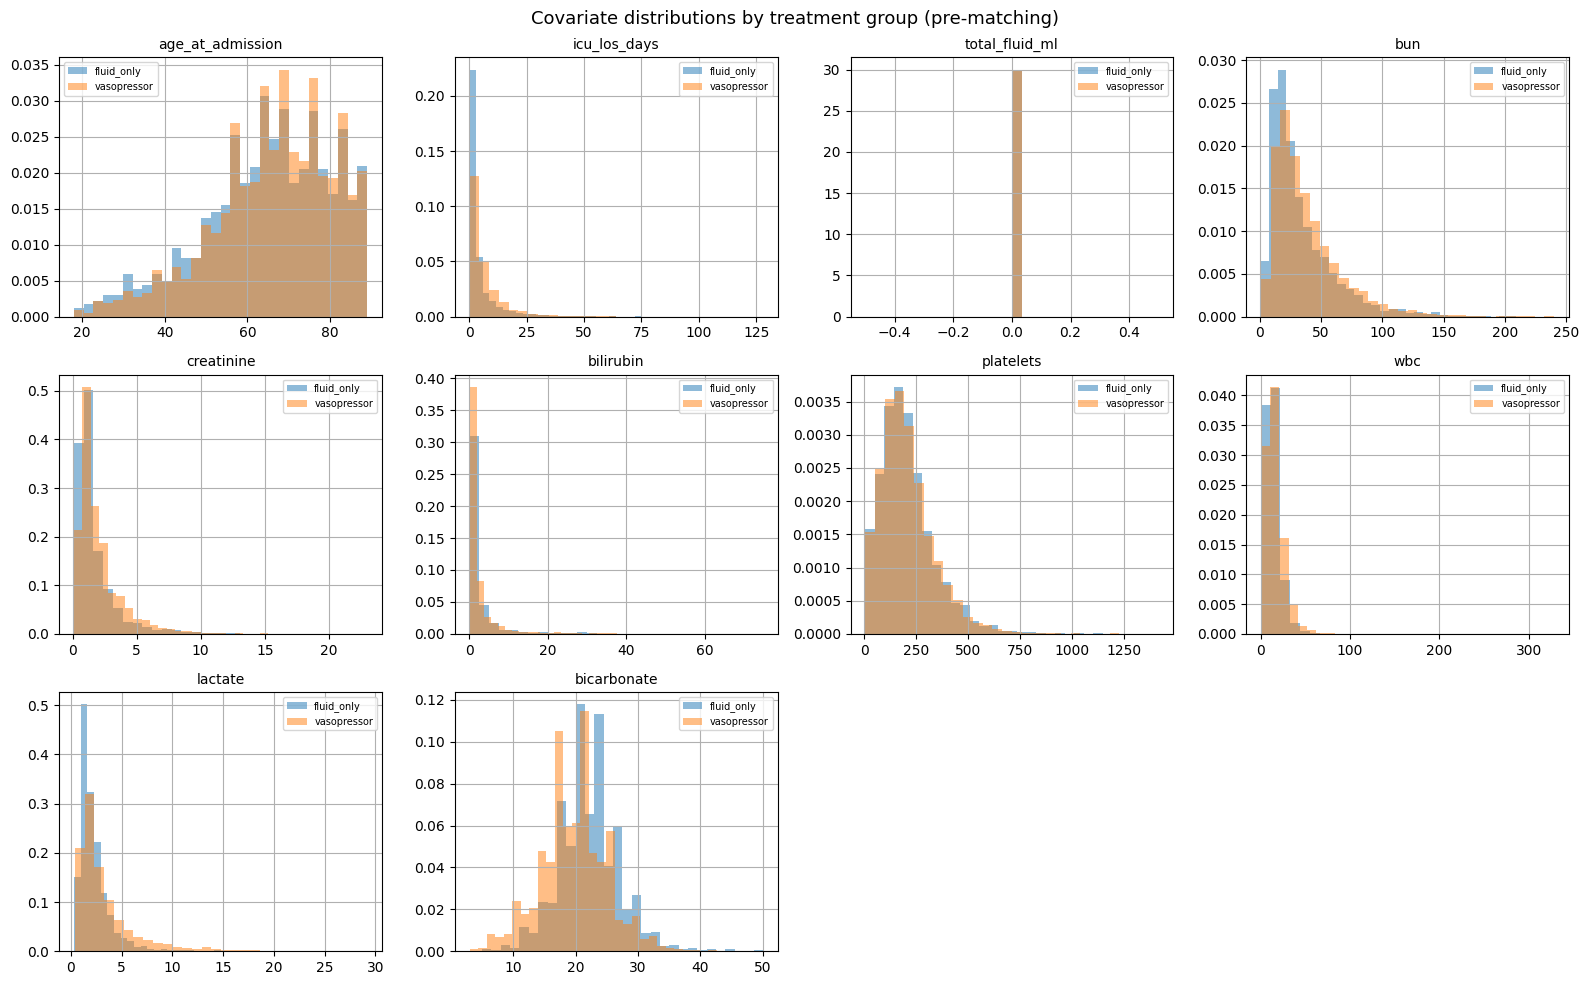

In [7]:
# ── 4. continuous covariate distributions by treatment group ──────────────────

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COVARIATES):
    ax = axes[i]
    for label, grp in df.groupby("treatment_label"):
        grp[col].dropna().hist(ax=ax, alpha=0.5, bins=30, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.legend(fontsize=7)

# hide unused subplots
for j in range(len(CONTINUOUS_COVARIATES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Covariate distributions by treatment group (pre-matching)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/01_covariate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# ── 5. standardized mean difference (SMD) table ───────────────────────────────
# SMD > 0.1 indicates meaningful imbalance — these are your priority confounders
# This table goes directly into your README and writeup


def compute_smd(df, col, treatment_col="treatment_group"):
    """SMD for a continuous variable between two groups."""
    g1 = df.loc[df[treatment_col] == 1, col].dropna()
    g0 = df.loc[df[treatment_col] == 0, col].dropna()

    mean_diff = g1.mean() - g0.mean()
    pooled_sd = np.sqrt((g1.std() ** 2 + g0.std() ** 2) / 2)

    if pooled_sd == 0:
        return np.nan
    return abs(mean_diff / pooled_sd)


smd_rows = []
for col in CONTINUOUS_COVARIATES:
    vasc = df.loc[df["treatment_group"] == 1, col]
    fluid = df.loc[df["treatment_group"] == 0, col]
    smd_rows.append(
        {
            "covariate": col,
            "vasopressor_mean": vasc.astype(pd.Float32Dtype()).mean().round(2),
            "fluid_only_mean": fluid.astype(pd.Float32Dtype()).mean().round(2),
            "vasopressor_n": vasc.notna().sum(),
            "fluid_only_n": fluid.notna().sum(),
            "smd": round(compute_smd(df, col), 3),
        }
    )

smd_df = pd.DataFrame(smd_rows).sort_values("smd", ascending=False)

print("=== Pre-matching SMD table ===")
print(smd_df.to_string(index=False))
print(f"\nCovariates with SMD > 0.1: {(smd_df['smd'] > 0.1).sum()}")


=== Pre-matching SMD table ===
       covariate  vasopressor_mean  fluid_only_mean  vasopressor_n  fluid_only_n   smd
     bicarbonate         19.780001        21.969999           4927          3496 0.426
         lactate          3.370000         2.300000           4610          2513 0.425
    icu_los_days          6.910000         4.580000           6023          4941 0.300
      creatinine          2.130000         1.730000           4929          3501 0.221
             bun         38.259998        33.549999           4923          3496 0.171
             wbc         16.010000        14.050000           4770          3296 0.162
age_at_admission         66.290001        64.860001           6023          4941 0.095
       platelets        208.500000       208.910004           4778          3300 0.003
       bilirubin          2.690000         2.700000           3149          1930 0.002
  total_fluid_ml          0.000000         0.000000           6023          4941   NaN

Covariates 

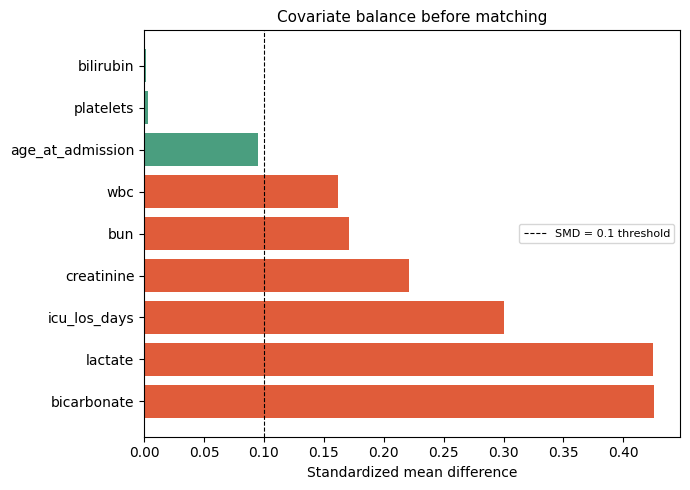

In [9]:
# ── 6. SMD plot (love plot) ───────────────────────────────────────────────────
# Standard way to present balance in RWE papers — include this in your writeup

fig, ax = plt.subplots(figsize=(7, 5))

colors = ["#e05c3a" if s > 0.1 else "#4a9e7f" for s in smd_df["smd"]]
ax.barh(smd_df["covariate"], smd_df["smd"], color=colors, edgecolor="none")
ax.axvline(
    0.1, color="black", linestyle="--", linewidth=0.8, label="SMD = 0.1 threshold"
)
ax.set_xlabel("Standardized mean difference")
ax.set_title("Covariate balance before matching", fontsize=11)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/01_love_plot_prematch.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# ── 7. categorical covariate breakdown ───────────────────────────────────────

for col in CATEGORICAL_COVARIATES:
    print(f"\n=== {col} by treatment group ===")
    ct = pd.crosstab(df[col], df["treatment_label"], normalize="columns").round(3) * 100
    print(ct.to_string())



=== gender by treatment group ===
treatment_label  fluid_only  vasopressor
gender                                  
F                      43.1         44.2
M                      56.9         55.8

=== race by treatment group ===
treatment_label                            fluid_only  vasopressor
race                                                              
AMERICAN INDIAN/ALASKA NATIVE                     0.3          0.3
ASIAN                                             1.5          1.3
ASIAN - ASIAN INDIAN                              0.3          0.3
ASIAN - CHINESE                                   1.6          1.3
ASIAN - KOREAN                                    0.0          0.1
ASIAN - SOUTH EAST ASIAN                          0.6          0.4
BLACK/AFRICAN                                     0.5          0.4
BLACK/AFRICAN AMERICAN                           11.1          8.8
BLACK/CAPE VERDEAN                                0.7          0.7
BLACK/CARIBBEAN ISLAND         

=== Raw 28-day mortality ===
                 deaths     n  mortality_rate
treatment_label                              
fluid_only          857  4941           0.173
vasopressor        1927  6023            0.32

=== Time-to-event summary ===
                  count  mean   std  min  25%  50%   75%    max
treatment_label                                                
fluid_only       4941.0  14.1  15.4  0.0  5.0  9.0  17.0  216.0
vasopressor      6023.0  14.0  15.7  0.0  5.0  9.0  18.0  246.0


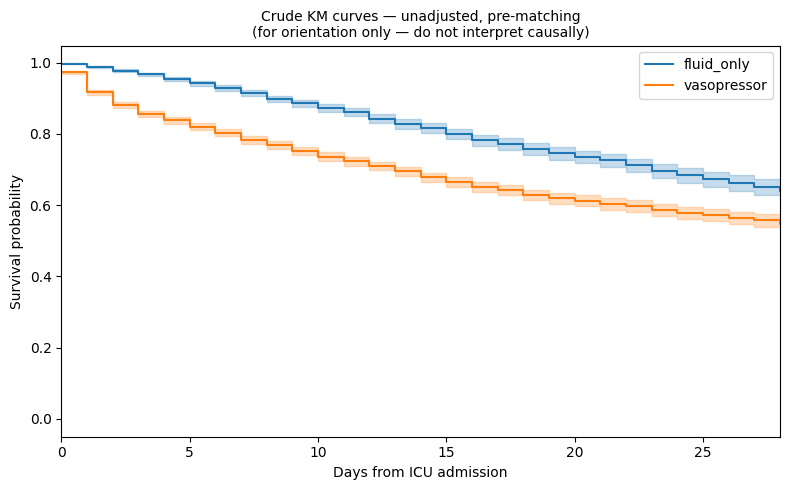

In [11]:
# ── 8. outcome overview ───────────────────────────────────────────────────────

print("=== Raw 28-day mortality ===")
print(
    df.groupby("treatment_label")["outcome_mortality_28d"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "deaths", "count": "n", "mean": "mortality_rate"})
    .round(3)
)

print("\n=== Time-to-event summary ===")
print(df.groupby("treatment_label")["time_to_event_days"].describe().round(1))

# Kaplan-Meier preview — crude (unadjusted), just for orientation
from lifelines import KaplanMeierFitter

fig, ax = plt.subplots(figsize=(8, 5))

for label, grp in df.groupby("treatment_label"):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=grp["time_to_event_days"],
        event_observed=grp["event_observed"],
        label=label,
    )
    kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_title(
    "Crude KM curves — unadjusted, pre-matching\n(for orientation only — do not interpret causally)",
    fontsize=10,
)
ax.set_xlabel("Days from ICU admission")
ax.set_ylabel("Survival probability")
ax.set_xlim(0, 28)
plt.tight_layout()
plt.savefig("../figures/01_km_crude.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# ── 9. save clean cohort for next notebook ────────────────────────────────────

df.to_parquet("../data/cohort_raw.parquet", index=False)
print(f"Saved cohort_raw.parquet — {df.shape[0]:,} rows")

print("\n=== Notebook 01 complete ===")
print("Next step: 02_psm.ipynb — imputation + propensity score matching")
print(
    f"Covariates with SMD > 0.1 that need balancing: "
    f"{list(smd_df.loc[smd_df['smd'] > 0.1, 'covariate'])}"
)


Saved cohort_raw.parquet — 10,964 rows

=== Notebook 01 complete ===
Next step: 02_psm.ipynb — imputation + propensity score matching
Covariates with SMD > 0.1 that need balancing: ['bicarbonate', 'lactate', 'icu_los_days', 'creatinine', 'bun', 'wbc']
